<a href="https://colab.research.google.com/github/deepzz-11/Heart-Disease-Prediction/blob/main/Heart_Disease_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv('/content/heart.csv')


In [3]:
print(df.head())
print(df.info())
print(df.describe())
print(df.shape)
print(df.columns)


   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N      0.0       Up             0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age    

In [4]:
print(df.isnull().sum())

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


In [5]:
print(df.duplicated().sum())

0


In [ ]:
df.drop_duplicates(inplace=True)
print(df.duplicated().sum())

0


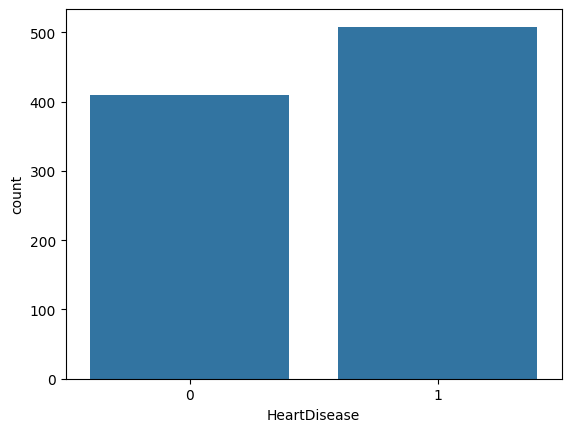

In [6]:
sns.countplot(x="HeartDisease", data=df)
plt.show()

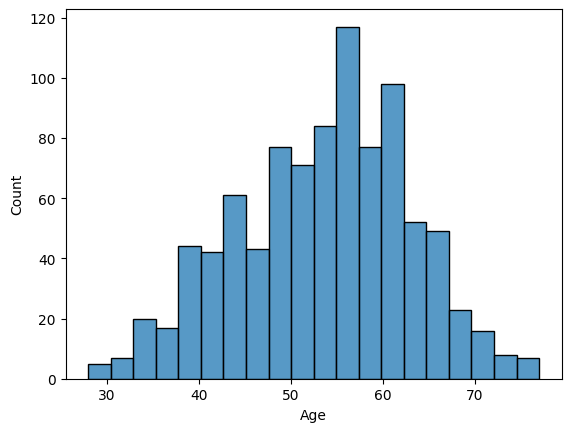

In [7]:
sns.histplot(df["Age"], bins=20)
plt.show()

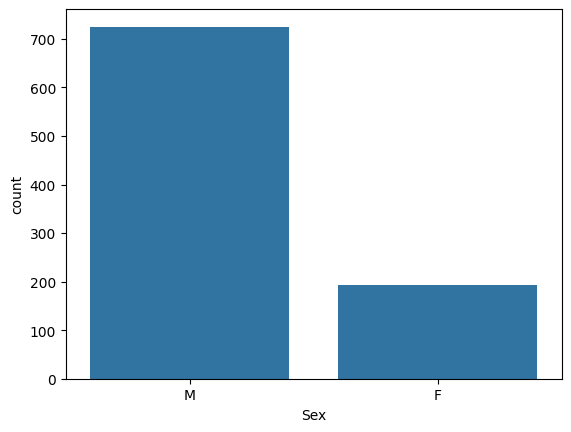

In [8]:
sns.countplot(x="Sex", data=df)
plt.show()

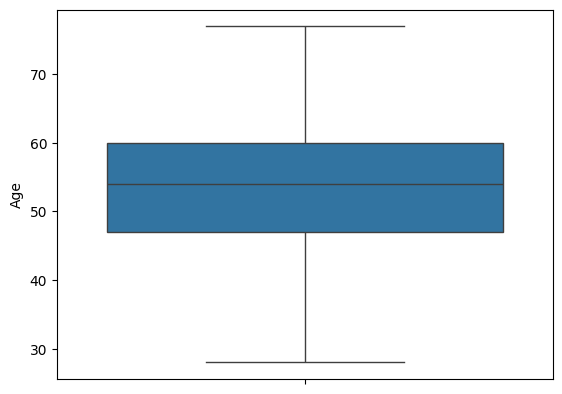

In [9]:
sns.boxplot(y=df["Age"])
plt.show()

In [28]:
X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]
print(X)
print(y)

     Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  \
0     40   M           ATA        140          289          0     Normal   
1     49   F           NAP        160          180          0     Normal   
2     37   M           ATA        130          283          0         ST   
3     48   F           ASY        138          214          0     Normal   
4     54   M           NAP        150          195          0     Normal   
..   ...  ..           ...        ...          ...        ...        ...   
913   45   M            TA        110          264          0     Normal   
914   68   M           ASY        144          193          1     Normal   
915   57   M           ASY        130          131          0     Normal   
916   57   F           ATA        130          236          0        LVH   
917   38   M           NAP        138          175          0     Normal   

     MaxHR ExerciseAngina  Oldpeak ST_Slope  
0      172              N      0.0       

In [29]:
X = pd.get_dummies(X, drop_first=True)

In [22]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [38]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier()

model.fit(X_train, y_train)

prediction = model.predict(X_test)




In [39]:
from sklearn.metrics import accuracy_score

prediction = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, prediction))

Accuracy: 0.8858695652173914


In [43]:
new_patient = pd.DataFrame({
    'Age':[45],
    'Sex':['M'],
    'ChestPainType':['ATA'],
    'RestingBP':[130],
    'Cholesterol':[230],
    'FastingBS':[0],
    'RestingECG':['Normal'],
    'MaxHR':[150],
    'ExerciseAngina':['N'],
    'Oldpeak':[1.2],
    'ST_Slope':['Up']
})

new_patient = pd.get_dummies(new_patient)
new_patient = new_patient.reindex(columns=X.columns, fill_value=0)

# Scale the new patient using the same scaler
new_patient = scaler.transform(new_patient)

prediction = model.predict(new_patient)

print("Prediction:", prediction)

if prediction[0] == 1:
    print("Heart Disease Detected")
else:
    print("No Heart Disease")

Prediction: [0]
No Heart Disease


In [46]:
new_patient = pd.DataFrame({
    'Age':[72],
    'Sex':['M'],
    'ChestPainType':['ASY'],
    'RestingBP':[180],
    'Cholesterol':[350],
    'FastingBS':[1],
    'RestingECG':['ST'],
    'MaxHR':[90],
    'ExerciseAngina':['Y'],
    'Oldpeak':[5.0],
    'ST_Slope':['Down']
})
new_patient = pd.get_dummies(new_patient)
new_patient = new_patient.reindex(columns=X.columns, fill_value=0)

# Scale the new patient using the same scaler
new_patient = scaler.transform(new_patient)

prediction = model.predict(new_patient)

print("Prediction:", prediction)

if prediction[0] == 1:
    print("Heart Disease Detected")
else:
    print("No Heart Disease")

Prediction: [1]
Heart Disease Detected
